In [2]:
require(data.table)
require(tidyverse)
require(phyloseq)
require(ggplot2)
require(RColorBrewer)
require(metacoder)
require(vegan)
require(DESeq2)

In [ ]:

#look at how many reads per sample, are there any samples needed to exclude
# dig into Date_16S
## post dada2 (before making ps object)- distribution of read lengths are the same (specif for Date_16S)
### track df
# rerun post phyloseq 

## post dada2 16S figures to find what data we are working with
### reads distributed (across samples, spec, Health_status, seq_run, Month_year)

# using vegan to map out stats and ordination plots for 16S sequences

In [3]:
ps<-readRDS(file = "/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/BEL_16S_ITS2/BEL_16S_outputs/ps_16S.rds")
#removing any taxa that don't show up in any samples to speed up the process
ps <- prune_taxa(taxa_sums(ps) > 0, ps)
ps

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 193447 taxa and 470 samples ]
sample_data() Sample Data:       [ 470 samples by 9 sample variables ]
tax_table()   Taxonomy Table:    [ 193447 taxa by 6 taxonomic ranks ]

In [5]:
#isolate just bacteria
ps_bac=subset_taxa(ps, Kingdom=="Bacteria")
ps_bac
#remove chloroplast order
ps_nochlo=subset_taxa(ps_bac, Order!="Chloroplast")
ps_nochlo
#remove mitochondria family
ps_nomit=subset_taxa(ps_nochlo, Family!="Mitochondria")
ps_nomit

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 177420 taxa and 470 samples ]
sample_data() Sample Data:       [ 470 samples by 9 sample variables ]
tax_table()   Taxonomy Table:    [ 177420 taxa by 6 taxonomic ranks ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 130388 taxa and 470 samples ]
sample_data() Sample Data:       [ 470 samples by 9 sample variables ]
tax_table()   Taxonomy Table:    [ 130388 taxa by 6 taxonomic ranks ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 64055 taxa and 470 samples ]
sample_data() Sample Data:       [ 470 samples by 9 sample variables ]
tax_table()   Taxonomy Table:    [ 64055 taxa by 6 taxonomic ranks ]

In [ ]:
#dont normalize before removing mit and chlo

In [6]:
#normalizing ps by converting rawcounts into relative abundances
#so samples with more reads wont be over represented
#using ps bc only to the count data (OTU table), while preserving the rest of the object
ps_norm = transform_sample_counts(ps_nomit, function(x) 1E6 * x / sum(x))
ps_norm

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 64055 taxa and 470 samples ]
sample_data() Sample Data:       [ 470 samples by 9 sample variables ]
tax_table()   Taxonomy Table:    [ 64055 taxa by 6 taxonomic ranks ]

In [7]:
# convert the sample_data() within a phyloseq object to a vegan compatible data object
pssd2veg <- function(ps_norm) {
  sd_nomit <- sample_data(ps_norm)
  return(as(sd_nomit,"data.frame"))
}
#using phyloseq nmds plot no chloroplast
sample_nomit <- pssd2veg(ps_norm)

In [8]:
class(sample_nomit)

[1] "data.frame"

In [9]:
# convert the otu_table() within a phyloseq object to a vegan compatible data object
psotu2veg <- function(ps_norm) {
  otu_nomit <- otu_table(ps_norm)
  if (taxa_are_rows(otu_nomit)) {
    otu_nomit <- t(otu_nomit)
  }
  return(as(otu_nomit, "matrix"))
}

# Extract normalized OTU matrix and sample data
otu_nomit <- psotu2veg(ps_norm)

In [10]:
class(otu_nomit)

[1] "matrix" "array"

### clean sample metadata

In [11]:
#save sammple names as a column so tidy doesn't get rid of it during filtering
sample_nomit$SampleID <- rownames(sample_nomit)

In [12]:
head(sample_nomit)

,Health_status,colony,Date_16S,Condition,Species,Month_year,Seq_run,Transect,DateFormatted,SampleID
,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<int>,<chr>,<date>,<chr>
012024_BEL_CBC_T1_557_SSID,Healthy,1_3,3_4_2025,Healthy,SSID,Jan 2024,1,CBC30N,2024-01-10,012024_BEL_CBC_T1_557_SSID
012024_BEL_CBC_T1_559_MCAV,Healthy,1_24,8_22_2025,Healthy,MCAV,Jan 2024,2,CBC30N,2024-01-10,012024_BEL_CBC_T1_559_MCAV
012024_BEL_CBC_T1_563_PSTR,Healthy,1_12,3_6_2025,Healthy,PSTR,Jan 2024,1,CBC30N,2024-01-10,012024_BEL_CBC_T1_563_PSTR
012024_BEL_CBC_T1_565_PAST,Bleached_Tissue,1_21,2_10_2026,CLP,PAST,Jan 2024,4,CBC30N,2024-01-10,012024_BEL_CBC_T1_565_PAST
012024_BEL_CBC_T2_585_OFAV,Healthy,2_76,2_10_2026,Healthy,OFAV,Jan 2024,4,SR30N,2024-01-12,012024_BEL_CBC_T2_585_OFAV
012024_BEL_CBC_T2_587_SSID,Bleached_Tissue,2_72,1_8_2026,CLB,SSID,Jan 2024,3,SR30N,2024-01-12,012024_BEL_CBC_T2_587_SSID


In [13]:
# 2. reorder MonthYear as a factor in chronological order
sample_nomit$Month_year <- factor(sample_nomit$Month_year,
        levels = unique(sample_nomit$Month_year[order(sample_nomit$DateFormatted)])
)

In [14]:
## check to make sure meta and otu table are still compatible

# Should return TRUE
all(rownames(sample_nomit) == rownames(otu_nomit))

[1] TRUE

# vegan cluster analysis

In [15]:
class(otu_nomit)
class(sample_nomit)
otu_df <- as.data.frame(otu_nomit)

[1] "matrix" "array"

[1] "data.frame"

In [16]:
head(otu_df)

,GCAAGCGTTGTTCGGAATTATTGGGCGTAAAGGGCATGTAGGTGGTTATATAAGTGTGGATTTAAAGACCGGAGCTTAACTCTGTGTATGGTCTGCAAACTGTATGACTAGAGTGCAGGAAGGGAGACTGGAATTCCATGTGTAAGGGTAATATCTGTAGATATGTGGAAGAACATCTGTGGCGAAGGCGAGTCTCTAGCCTGCAACTGACGCTAATGTGCGAAAGTGTGGGG,GCAAGCGTTGTCCGGATTTATTGGGCGTAAAGAGCTCGTAGGCGGTTGCGTAAGTCGGATGTGAAAACTCAGGGCTCAACCCGGAGACGCCATTCGATACTGCGCTGACTAGAGTCCGGTAGGGGAGCATGGAATTCCTGGTGTAGCGGTGAAATGCGCAGATATCAGGAGGAACACCAGTGGCGAAGGCGGTGCTCTGGGCCGGTACTGACGCTGAGGAGCGAAAGCGTGGGT,ACGAACGTTATCCGGAATTACTGGGCGTAAAGGGCGCGCAGGCGGCCTTGCAAGACGGACATGAAAGCCTGGGGCTCAACTCCGGGAGGCTGTCGGTGACTGCGGGGCTTGAGGGTGAGAGAGGGGTGTGGAATTCCGCGTGTAGTGGTGAAATGCGTAGAGATGCGGAGGAACACCGGAGGCGAAGGCGGCACCCTGGCTCACAACTGACGCTGAGGCGCGAAAGCATGGGG,GCAAGCGTTATTCGGAATTACTGGGCGTAAAGGGCGCGTAGGCGGCCTGTTAAGTGAGAAGTGAAAGCCCACGGCTTAACCGTGGAACTGCTTCTCATACTGGCAGGCTAGAGTATGGGAGAGGAAAGTGGAATTCCCGGTGTAGCGGTGAAATGCGTAGAGATCGGGAGGAACACCAGTGGCGAAGGCGACTTTCTGGACCATAACTGACGCTGATGCGCGAAAGCGTGGGT,GCAAGCGTTATCCGGAATCACTGGGTTTAAAGGGTGCGTAGGCGGCGCTATAAGTCAGAGGTGAAAGCCCACCGCTCAACGGTGGAACTGCCTTTGATACTGTAGAGCTTGAATCAGGCTGAGGTTAGCGGAATGTGTCATGTAGCGGTGAAATGCATAGATATGACATAGAACACCAATTGCGAAGGCAGCTGACTAGACCTGTATTGACGCTGAGGCACGAAAGCGTGGGG,GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGTTTATCAAGTCAGATGTGAAAGCCCTAGGCTTAACCTAGGAACTGCATTTGAAACTGATAAGCTAGAGTATGGTAGAGGAAAGTGGAATTTCTGGTGTAGCGGTGAAATGCGTAAATATCAGAAGGAACATCAATGGCGAAGGCAACTTTCTGGACCAATACTGACGCTGAGGTACGAAAGCGTGGGT,GCAAGCGTTATTCGGAATTATTGGGCGTAAAGGGCGCGTAGGCGGCCTGGCAAGTCAGGGGTGAAATCCCTCGGCTCAACCGAGGAACTGCCTCTGAAACTGCTTGGCTTGAGGCCGGGAGAGGGTAGTGGAATTCCCAGTGTAGCGGTGAAATGCGTAGATATTGGGAGGAACACCGGTGGCGAAGGCGGCTACCTGGACCGGTTCTGACGCTGAGGCGCGAAAGTGTGGGG,GCTAGCGTTGTTCGGAATTACTGGGCGTAAAGCGCGCGTAGGCGGGCTGTTAAGTCGGGGGTGAAATCCCGGGGCTCAACCCCGGAACTGCCCCCGATACTGGCAGCCTAGAGGACGGAAGAGGCGAGTGGAATGTCGAGTGTAGAGGTGAAATTCGTAGATATTCGACGGAACACCCGTGGCGAAGGCGGCTCGCTGGTCCGTATCTGACGCTGAGGTGCGAAAGCGTGGGG,GCAAGCGTTATCCGGAATCACTGGGTTTAAAGGGTGCGTAGGCGGACAAGTAAGTCAGTGGTGAAAGCCTGCAGCTTAACTGTAGAATTGCCTTTGATACTGCTTGTCTTGAATTAGGATGAGGTATGCGGAATGTGACATGTAGCGGTGAAATGCATAGATATGTCATAGAACACCAATTGCGAAGGCAGCATACTAGACCTATATTGACGCTGAGGCACGAAAGCGTGGGG,GCAAGCGTTGTCCGGATTCATTGGGCGTAAAGGGCTCGTAGGCGGTTTGGTAAGTCGGGTGTAAAAACTCAGGGCTCAACTCTGAGACGCCACTCGATACTGCCATGACTAGAGTCCGGTAGAGGAGTGTAGAATTCCTGGTGTAGCGGTGAAATGCGCAGATATCAGGAGGAATACCGACAGCGAAGGCAGCACTCTGGGCCGGTACTGACGCTGAGGAGCGAAAGCGTGGGG,⋯,CCTAGCGTTGTTCGGAATTACTGGGCGTAAAGCGGGTGTAGGTGGATTCGCAAGTCAGATGTGAAAGCCCGGGGCTCAACCTCGGAACTGCATTTGATACTGCGAATCTTGAGTACTGGAGAGGGTAGCGGAATTCCTGGTGTAGTGGTGAAATACGTAGATATCAGGAGGAACATCGGTGGCGAAGGCGGCTGCCTGGCCAGATACTGACACTCAGACCCGAAAGCGTGGGT,GCAAGCGTTGTTCGGAATTACTGGGCGTAAAGGGCGTGTAGGCGGACCGATTAGTTATAGGTGAAATCCCGGGGCTCAACCCCGGAAGTGCTTATAAAACTGTCGGTCTAGAGGGAGTCAGAGGTTAGCGGAATTCCTGGTGTAGAGGTGAAATTCGTAGATATCAGGAAGAACACCGGAGGCGAAAGCGGCTAACTGGGACTTTACTGACGCTGAGGCGCGAAAGCATGGGG,GCGAGCGTTATTCGGAATCATTGGGCGTAAAGGGCGCGTAGGCGGCTTAGCAAGTCAGTGGTGAAATCCCTCGGCTCAACCGAGGAACTGCCTCTGAAACTGCTTCGCTTGAGGCCGGGAGAGGGGAGTGGAATTCCAGGTGTAGCGGTGAAATGCGTAGAGATCTGGAGGAACATCAGTGGCGAAGGCGACTCCCTGGCCAAAGACTGACGCTCATGTGCGAAAGTGTGGGT,GCAAGCGTTGTTCGGAATTACTGGGCGTAAAGGGCGGGCAGGCGGTCTGTTAAGTCTTTTGTGAAAATCCGGGGCTCAACTCCGTGAAATGCAGAAGATACTGTCAGACTAGAGACCAGTAGAGGCTAGCGGAATTCCTGGTGTAGCGGTGAAATGCGTAGAGATCTGAAGGAACATCAGTGGCGAAGGCGACTGTCTGGGCTGATACTGACGCTGAGGTGCGAAAGCGTGGGG,GCAAGCATTAATCGGAATTATTGGGCGTAAAGGGCGCGTAGGCGGAATTGCAAGTCAGATGTGAAATACCGAGGCTTAACCTCGGTGCTGCATTTGAAACTGCAAATCTAGAGGGTAGACGGAGAAAACGGAATTCTACATGTAGCGGTGGAATGCGTGGATATGTAGAAGAACACCTGTGGCGAAAGCGGTTTTCTAGTTTATTCCTGACGCTGAGGCGCGAGAGCAAGGGG,GCAAACGTTGCTCGGAATCATTGGGCGTAAAGCGCACGTAGGCGGCCTTGCAAGTTGGGTGTGAAAGCCCGGGGCTCAACCCCGGAAGTGCACCCAAAACTGCCTGGCTTGAATACCAGAGGGGAGCAGAGAATTCCCGGTGTAGAGGTGAAATTCGTAGATATTGGGAAGAACACCAGTGGCGAAGGCGGCTATCTGGTCCGGTACTGACGCTGAGGCGCGAAAGCGTGGGG,GCAAGCGTTATCCGGATTTACTGGGTTTAAAGGGTGCGTAGGCGGCTCTTTAAGTCAGTGGTGAAAGCCTGCAGCTTAACTGTAGAACTGCCATTGATACTGGGGGCCTTGAGTACAGATAAGGTAGGCGGAATTGATGATGTAGCGGTGAAATGCATAGATACCATAAGGAATACCCATAGCGAAGGCACCTTACTGGCCTTTTACTGACGCTGAGACACGAAAGCGTGGGT,GCAAGCGTTATTCGGA

In [17]:
# check to make sure otu and sample are compatible
class(sample_nomit)
class(otu_df)

# merge otu and sam_clean by sample ID
otu_df$SampleID <- rownames(otu_df)

[1] "data.frame"

[1] "data.frame"

In [18]:
otu_merged <- merge(otu_df, sample_nomit, by = "SampleID",
                    all = TRUE, sort = FALSE)

In [19]:
head(otu_merged)

,SampleID,GCAAGCGTTGTTCGGAATTATTGGGCGTAAAGGGCATGTAGGTGGTTATATAAGTGTGGATTTAAAGACCGGAGCTTAACTCTGTGTATGGTCTGCAAACTGTATGACTAGAGTGCAGGAAGGGAGACTGGAATTCCATGTGTAAGGGTAATATCTGTAGATATGTGGAAGAACATCTGTGGCGAAGGCGAGTCTCTAGCCTGCAACTGACGCTAATGTGCGAAAGTGTGGGG,GCAAGCGTTGTCCGGATTTATTGGGCGTAAAGAGCTCGTAGGCGGTTGCGTAAGTCGGATGTGAAAACTCAGGGCTCAACCCGGAGACGCCATTCGATACTGCGCTGACTAGAGTCCGGTAGGGGAGCATGGAATTCCTGGTGTAGCGGTGAAATGCGCAGATATCAGGAGGAACACCAGTGGCGAAGGCGGTGCTCTGGGCCGGTACTGACGCTGAGGAGCGAAAGCGTGGGT,ACGAACGTTATCCGGAATTACTGGGCGTAAAGGGCGCGCAGGCGGCCTTGCAAGACGGACATGAAAGCCTGGGGCTCAACTCCGGGAGGCTGTCGGTGACTGCGGGGCTTGAGGGTGAGAGAGGGGTGTGGAATTCCGCGTGTAGTGGTGAAATGCGTAGAGATGCGGAGGAACACCGGAGGCGAAGGCGGCACCCTGGCTCACAACTGACGCTGAGGCGCGAAAGCATGGGG,GCAAGCGTTATTCGGAATTACTGGGCGTAAAGGGCGCGTAGGCGGCCTGTTAAGTGAGAAGTGAAAGCCCACGGCTTAACCGTGGAACTGCTTCTCATACTGGCAGGCTAGAGTATGGGAGAGGAAAGTGGAATTCCCGGTGTAGCGGTGAAATGCGTAGAGATCGGGAGGAACACCAGTGGCGAAGGCGACTTTCTGGACCATAACTGACGCTGATGCGCGAAAGCGTGGGT,GCAAGCGTTATCCGGAATCACTGGGTTTAAAGGGTGCGTAGGCGGCGCTATAAGTCAGAGGTGAAAGCCCACCGCTCAACGGTGGAACTGCCTTTGATACTGTAGAGCTTGAATCAGGCTGAGGTTAGCGGAATGTGTCATGTAGCGGTGAAATGCATAGATATGACATAGAACACCAATTGCGAAGGCAGCTGACTAGACCTGTATTGACGCTGAGGCACGAAAGCGTGGGG,GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGTTTATCAAGTCAGATGTGAAAGCCCTAGGCTTAACCTAGGAACTGCATTTGAAACTGATAAGCTAGAGTATGGTAGAGGAAAGTGGAATTTCTGGTGTAGCGGTGAAATGCGTAAATATCAGAAGGAACATCAATGGCGAAGGCAACTTTCTGGACCAATACTGACGCTGAGGTACGAAAGCGTGGGT,GCAAGCGTTATTCGGAATTATTGGGCGTAAAGGGCGCGTAGGCGGCCTGGCAAGTCAGGGGTGAAATCCCTCGGCTCAACCGAGGAACTGCCTCTGAAACTGCTTGGCTTGAGGCCGGGAGAGGGTAGTGGAATTCCCAGTGTAGCGGTGAAATGCGTAGATATTGGGAGGAACACCGGTGGCGAAGGCGGCTACCTGGACCGGTTCTGACGCTGAGGCGCGAAAGTGTGGGG,GCTAGCGTTGTTCGGAATTACTGGGCGTAAAGCGCGCGTAGGCGGGCTGTTAAGTCGGGGGTGAAATCCCGGGGCTCAACCCCGGAACTGCCCCCGATACTGGCAGCCTAGAGGACGGAAGAGGCGAGTGGAATGTCGAGTGTAGAGGTGAAATTCGTAGATATTCGACGGAACACCCGTGGCGAAGGCGGCTCGCTGGTCCGTATCTGACGCTGAGGTGCGAAAGCGTGGGG,GCAAGCGTTATCCGGAATCACTGGGTTTAAAGGGTGCGTAGGCGGACAAGTAAGTCAGTGGTGAAAGCCTGCAGCTTAACTGTAGAATTGCCTTTGATACTGCTTGTCTTGAATTAGGATGAGGTATGCGGAATGTGACATGTAGCGGTGAAATGCATAGATATGTCATAGAACACCAATTGCGAAGGCAGCATACTAGACCTATATTGACGCTGAGGCACGAAAGCGTGGGG,⋯,GCGGGTAATACGGAGGGTGCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGCGCGTAGGTGGCTTGATAAGCCGGTTGTGAAAGCCCCGGGCTCAACCTGGGAACGGCATCCGGAACTGTCAAGCTAGAGTGCAGGAGAGGAAGGTAGAATTCCCGGTGTAGCGGTGAAATGCGTAGAGATCGGGAGGAATACCAGTGGCGAAGGCGGCCTTCTGGACTGACACTGACACTGAGGTGCGAAAGCGTGGGT,Health_status,colony,Date_16S,Condition,Species,Month_year,Seq_run,Transect,DateFormatted
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<int>,<chr>,<date>
1,012024_BEL_CBC_T1_557_SSID,0,0,0,0,0,0,0,0,0,⋯,0,Healthy,1_3,3_4_2025,Healthy,SSID,Jan 2024,1,CBC30N,2024-01-10
2,012024_BEL_CBC_T1_559_MCAV,0,0,0,0,0,0,0,0,0,⋯,0,Healthy,1_24,8_22_2025,Healthy,MCAV,Jan 2024,2,CBC30N,2024-01-10
3,012024_BEL_CBC_T1_563_PSTR,0,0,0,0,0,0,0,0,0,⋯,0,Healthy,1_12,3_6_2025,Healthy,PSTR,Jan 2024,1,CBC30N,2024-01-10
4,012024_BEL_CBC_T1_565_PAST,0,0,0,0,0,0,0,0,0,⋯,0,Bleached_Tissue,1_21,2_10_2026,CLP,PAST,Jan 2024,4,CBC30N,2024-01-10
5,012024_BEL_CBC_T2_585_OFAV,0,0,0,0,0,0,0,0,0,⋯,0,Healthy,2_76,2_10_2026,Healthy,OFAV,Jan 2024,4,SR30N,2024-01-12
6,012024_BEL_CBC_T2_587_SSID,0,0,0,0,0,0,0,0,0,⋯,0,Bleached_Tissue,2_72,1_8_2026,CLB,SSID,Jan 2024,3,SR30N,2024-01-12


In [20]:
rownames(otu_merged) <- otu_merged$SampleID

In [21]:
otu_merged$SampleID <- NULL

In [22]:
class(otu_merged)
head(otu_merged)
nrow(otu_df)
nrow(otu_merged)
all(rownames(otu_df) == rownames(otu_merged))

[1] "data.frame"

,GCAAGCGTTGTTCGGAATTATTGGGCGTAAAGGGCATGTAGGTGGTTATATAAGTGTGGATTTAAAGACCGGAGCTTAACTCTGTGTATGGTCTGCAAACTGTATGACTAGAGTGCAGGAAGGGAGACTGGAATTCCATGTGTAAGGGTAATATCTGTAGATATGTGGAAGAACATCTGTGGCGAAGGCGAGTCTCTAGCCTGCAACTGACGCTAATGTGCGAAAGTGTGGGG,GCAAGCGTTGTCCGGATTTATTGGGCGTAAAGAGCTCGTAGGCGGTTGCGTAAGTCGGATGTGAAAACTCAGGGCTCAACCCGGAGACGCCATTCGATACTGCGCTGACTAGAGTCCGGTAGGGGAGCATGGAATTCCTGGTGTAGCGGTGAAATGCGCAGATATCAGGAGGAACACCAGTGGCGAAGGCGGTGCTCTGGGCCGGTACTGACGCTGAGGAGCGAAAGCGTGGGT,ACGAACGTTATCCGGAATTACTGGGCGTAAAGGGCGCGCAGGCGGCCTTGCAAGACGGACATGAAAGCCTGGGGCTCAACTCCGGGAGGCTGTCGGTGACTGCGGGGCTTGAGGGTGAGAGAGGGGTGTGGAATTCCGCGTGTAGTGGTGAAATGCGTAGAGATGCGGAGGAACACCGGAGGCGAAGGCGGCACCCTGGCTCACAACTGACGCTGAGGCGCGAAAGCATGGGG,GCAAGCGTTATTCGGAATTACTGGGCGTAAAGGGCGCGTAGGCGGCCTGTTAAGTGAGAAGTGAAAGCCCACGGCTTAACCGTGGAACTGCTTCTCATACTGGCAGGCTAGAGTATGGGAGAGGAAAGTGGAATTCCCGGTGTAGCGGTGAAATGCGTAGAGATCGGGAGGAACACCAGTGGCGAAGGCGACTTTCTGGACCATAACTGACGCTGATGCGCGAAAGCGTGGGT,GCAAGCGTTATCCGGAATCACTGGGTTTAAAGGGTGCGTAGGCGGCGCTATAAGTCAGAGGTGAAAGCCCACCGCTCAACGGTGGAACTGCCTTTGATACTGTAGAGCTTGAATCAGGCTGAGGTTAGCGGAATGTGTCATGTAGCGGTGAAATGCATAGATATGACATAGAACACCAATTGCGAAGGCAGCTGACTAGACCTGTATTGACGCTGAGGCACGAAAGCGTGGGG,GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGTTTATCAAGTCAGATGTGAAAGCCCTAGGCTTAACCTAGGAACTGCATTTGAAACTGATAAGCTAGAGTATGGTAGAGGAAAGTGGAATTTCTGGTGTAGCGGTGAAATGCGTAAATATCAGAAGGAACATCAATGGCGAAGGCAACTTTCTGGACCAATACTGACGCTGAGGTACGAAAGCGTGGGT,GCAAGCGTTATTCGGAATTATTGGGCGTAAAGGGCGCGTAGGCGGCCTGGCAAGTCAGGGGTGAAATCCCTCGGCTCAACCGAGGAACTGCCTCTGAAACTGCTTGGCTTGAGGCCGGGAGAGGGTAGTGGAATTCCCAGTGTAGCGGTGAAATGCGTAGATATTGGGAGGAACACCGGTGGCGAAGGCGGCTACCTGGACCGGTTCTGACGCTGAGGCGCGAAAGTGTGGGG,GCTAGCGTTGTTCGGAATTACTGGGCGTAAAGCGCGCGTAGGCGGGCTGTTAAGTCGGGGGTGAAATCCCGGGGCTCAACCCCGGAACTGCCCCCGATACTGGCAGCCTAGAGGACGGAAGAGGCGAGTGGAATGTCGAGTGTAGAGGTGAAATTCGTAGATATTCGACGGAACACCCGTGGCGAAGGCGGCTCGCTGGTCCGTATCTGACGCTGAGGTGCGAAAGCGTGGGG,GCAAGCGTTATCCGGAATCACTGGGTTTAAAGGGTGCGTAGGCGGACAAGTAAGTCAGTGGTGAAAGCCTGCAGCTTAACTGTAGAATTGCCTTTGATACTGCTTGTCTTGAATTAGGATGAGGTATGCGGAATGTGACATGTAGCGGTGAAATGCATAGATATGTCATAGAACACCAATTGCGAAGGCAGCATACTAGACCTATATTGACGCTGAGGCACGAAAGCGTGGGG,GCAAGCGTTGTCCGGATTCATTGGGCGTAAAGGGCTCGTAGGCGGTTTGGTAAGTCGGGTGTAAAAACTCAGGGCTCAACTCTGAGACGCCACTCGATACTGCCATGACTAGAGTCCGGTAGAGGAGTGTAGAATTCCTGGTGTAGCGGTGAAATGCGCAGATATCAGGAGGAATACCGACAGCGAAGGCAGCACTCTGGGCCGGTACTGACGCTGAGGAGCGAAAGCGTGGGG,⋯,GCGGGTAATACGGAGGGTGCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGCGCGTAGGTGGCTTGATAAGCCGGTTGTGAAAGCCCCGGGCTCAACCTGGGAACGGCATCCGGAACTGTCAAGCTAGAGTGCAGGAGAGGAAGGTAGAATTCCCGGTGTAGCGGTGAAATGCGTAGAGATCGGGAGGAATACCAGTGGCGAAGGCGGCCTTCTGGACTGACACTGACACTGAGGTGCGAAAGCGTGGGT,Health_status,colony,Date_16S,Condition,Species,Month_year,Seq_run,Transect,DateFormatted
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<int>,<chr>,<date>
012024_BEL_CBC_T1_557_SSID,0,0,0,0,0,0,0,0,0,0,⋯,0,Healthy,1_3,3_4_2025,Healthy,SSID,Jan 2024,1,CBC30N,2024-01-10
012024_BEL_CBC_T1_559_MCAV,0,0,0,0,0,0,0,0,0,0,⋯,0,Healthy,1_24,8_22_2025,Healthy,MCAV,Jan 2024,2,CBC30N,2024-01-10
012024_BEL_CBC_T1_563_PSTR,0,0,0,0,0,0,0,0,0,0,⋯,0,Healthy,1_12,3_6_2025,Healthy,PSTR,Jan 2024,1,CBC30N,2024-01-10
012024_BEL_CBC_T1_565_PAST,0,0,0,0,0,0,0,0,0,0,⋯,0,Bleached_Tissue,1_21,2_10_2026,CLP,PAST,Jan 2024,4,CBC30N,2024-01-10
012024_BEL_CBC_T2_585_OFAV,0,0,0,0,0,0,0,0,0,0,⋯,0,Healthy,2_76,2_10_2026,Healthy,OFAV,Jan 2024,4,SR30N,2024-01-12
012024_BEL_CBC_T2_587_SSID,0,0,0,0,0,0,0,0,0,0,⋯,0,Bleached_Tissue,2_72,1_8_2026,CLB,SSID,Jan 2024,3,SR30N,2024-01-12


[1] 470

[1] 470

[1] TRUE

## what is driving clustering?
vegan nmds

In [27]:
#after plotting # dimensions vs stress I see that my values are all <0.2 so is it okay (not the best for perfect interp)
#using k=2 bc I want to make a 2-D plot

# If you don`t provide a dissimilarity matrix, metaMDS automatically applies Bray-Curtis. So in our case, the results would have to be the same
NMDS_veg <- metaMDS(otu_nomit, k = 2, trymax = 100, trace = F)

Warning message in metaMDS(otu_nomit, k = 2, trymax = 100, trace = F):
“stress is (nearly) zero: you may have insufficient data”
Warning message in postMDS(out$points, dis, plot = max(0, plot - 1), ...):
“skipping half-change scaling: too few points below threshold”



***VECTORS

          NMDS1   NMDS2     r2 Pr(>r)    
Seq_run 0.13635 0.99066 0.4182  0.001 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
Permutation: free
Number of permutations: 999

***FACTORS:

Centroids:
                                      NMDS1   NMDS2
Health_statusBleached_Tissue        -0.0690 -0.0487
Health_statusDiseased_Margin         0.1494  0.0649
Health_statusDiseased_Tissue         0.1286  0.0811
Health_statusHealthy                -0.0205 -0.0086
colony1_12                          -0.1478 -0.0288
colony1_13                          -0.1778 -0.0322
colony1_14                           0.3683  0.0805
colony1_15                           0.6965  0.0356
colony1_16                           0.2051  0.1061
colony1_17                          -0.2847  0.1781
colony1_19                           0.3702  0.0819
colony1_2                            0.1252 -0.0258
colony1_20                           0.2060  0.1042
colony1_21                           

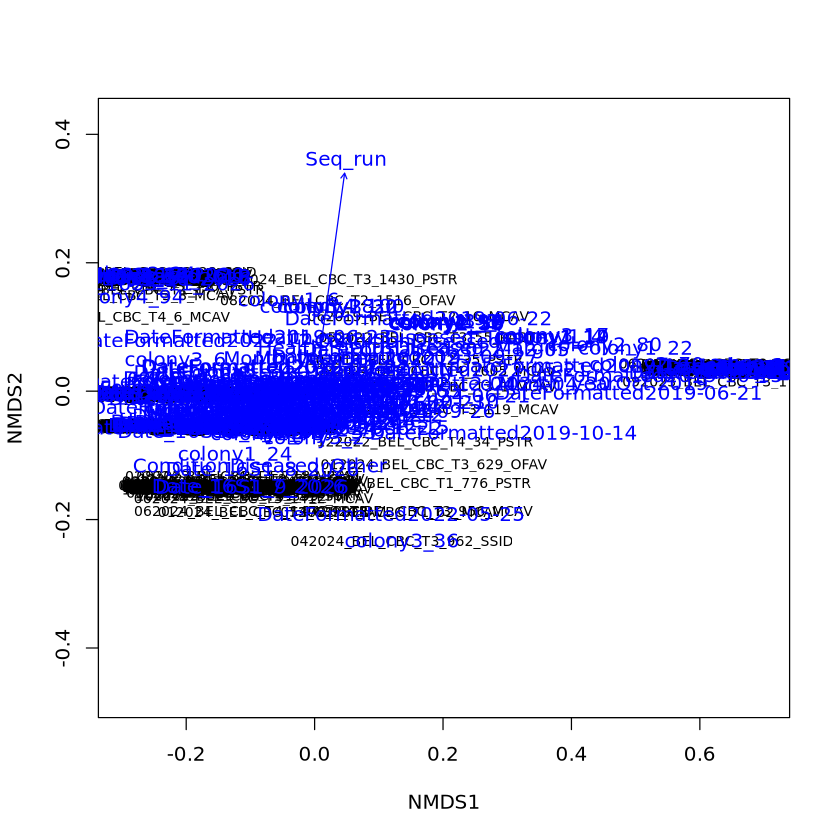

In [28]:
#vector fitting using a regression
# The function envfit will add the environmental variables as vectors to the ordination plot
ef <- envfit(NMDS_veg, sample_nomit, permu = 999)
ef

# The two last columns are of interest: the squared correlation coefficient and the associated p-value
# Plot the vectors of the significant correlations and interpret the plot
plot(NMDS_veg, type = "t", display = "sites")
plot(ef, p.max = 0.05)

- why isnt sequence run showing up in my goodness of fit test?
- ALSO, Health_status is now updated with Bleached_tissue for all samples, it is interesting that the Health_status variable is sig but not condition

In [29]:
#this one is species within transect with date as another variable
adonis2(vegdist(otu_nomit, method = "bray") ~ Date_16S + Month_year + Seq_run + Species + Health_status, data = sample_nomit)


,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Date_16S,29,16.2709140,0.069441437,1.133982,0.001
Month_year,11,5.5905457,0.023859479,1.027197,0.001
Seq_run,1,0.5018985,0.002142016,1.014397,0.003
Species,5,2.6376063,0.011256846,1.066184,0.001
Health_status,3,1.5047909,0.006422186,1.013788,0.069
Residual,420,207.8055546,0.886878037,NA,NA
Total,469,234.3113101,1.000000000,NA,NA


## PC clustering of host species with hellinger distance

convert otu_merged back to matrix to be able to use decostand()

In [38]:
# Hellinger distance, comparable to euclidean 
ord <- decostand(otu_nomit, method = "hellinger")

In [40]:
str(otu_merged$Species)
table(otu_merged$Species)

 chr [1:470] "SSID" "MCAV" "PSTR" "PAST" "OFAV" "SSID" "SSID" "PAST" "MCAV" ...



MCAV OANN OFAV PAST PSTR SSID 
 137   17   63   98   69   86 

In [43]:
# plot settings
options(repr.plot.width=20, repr.plot.height=15)

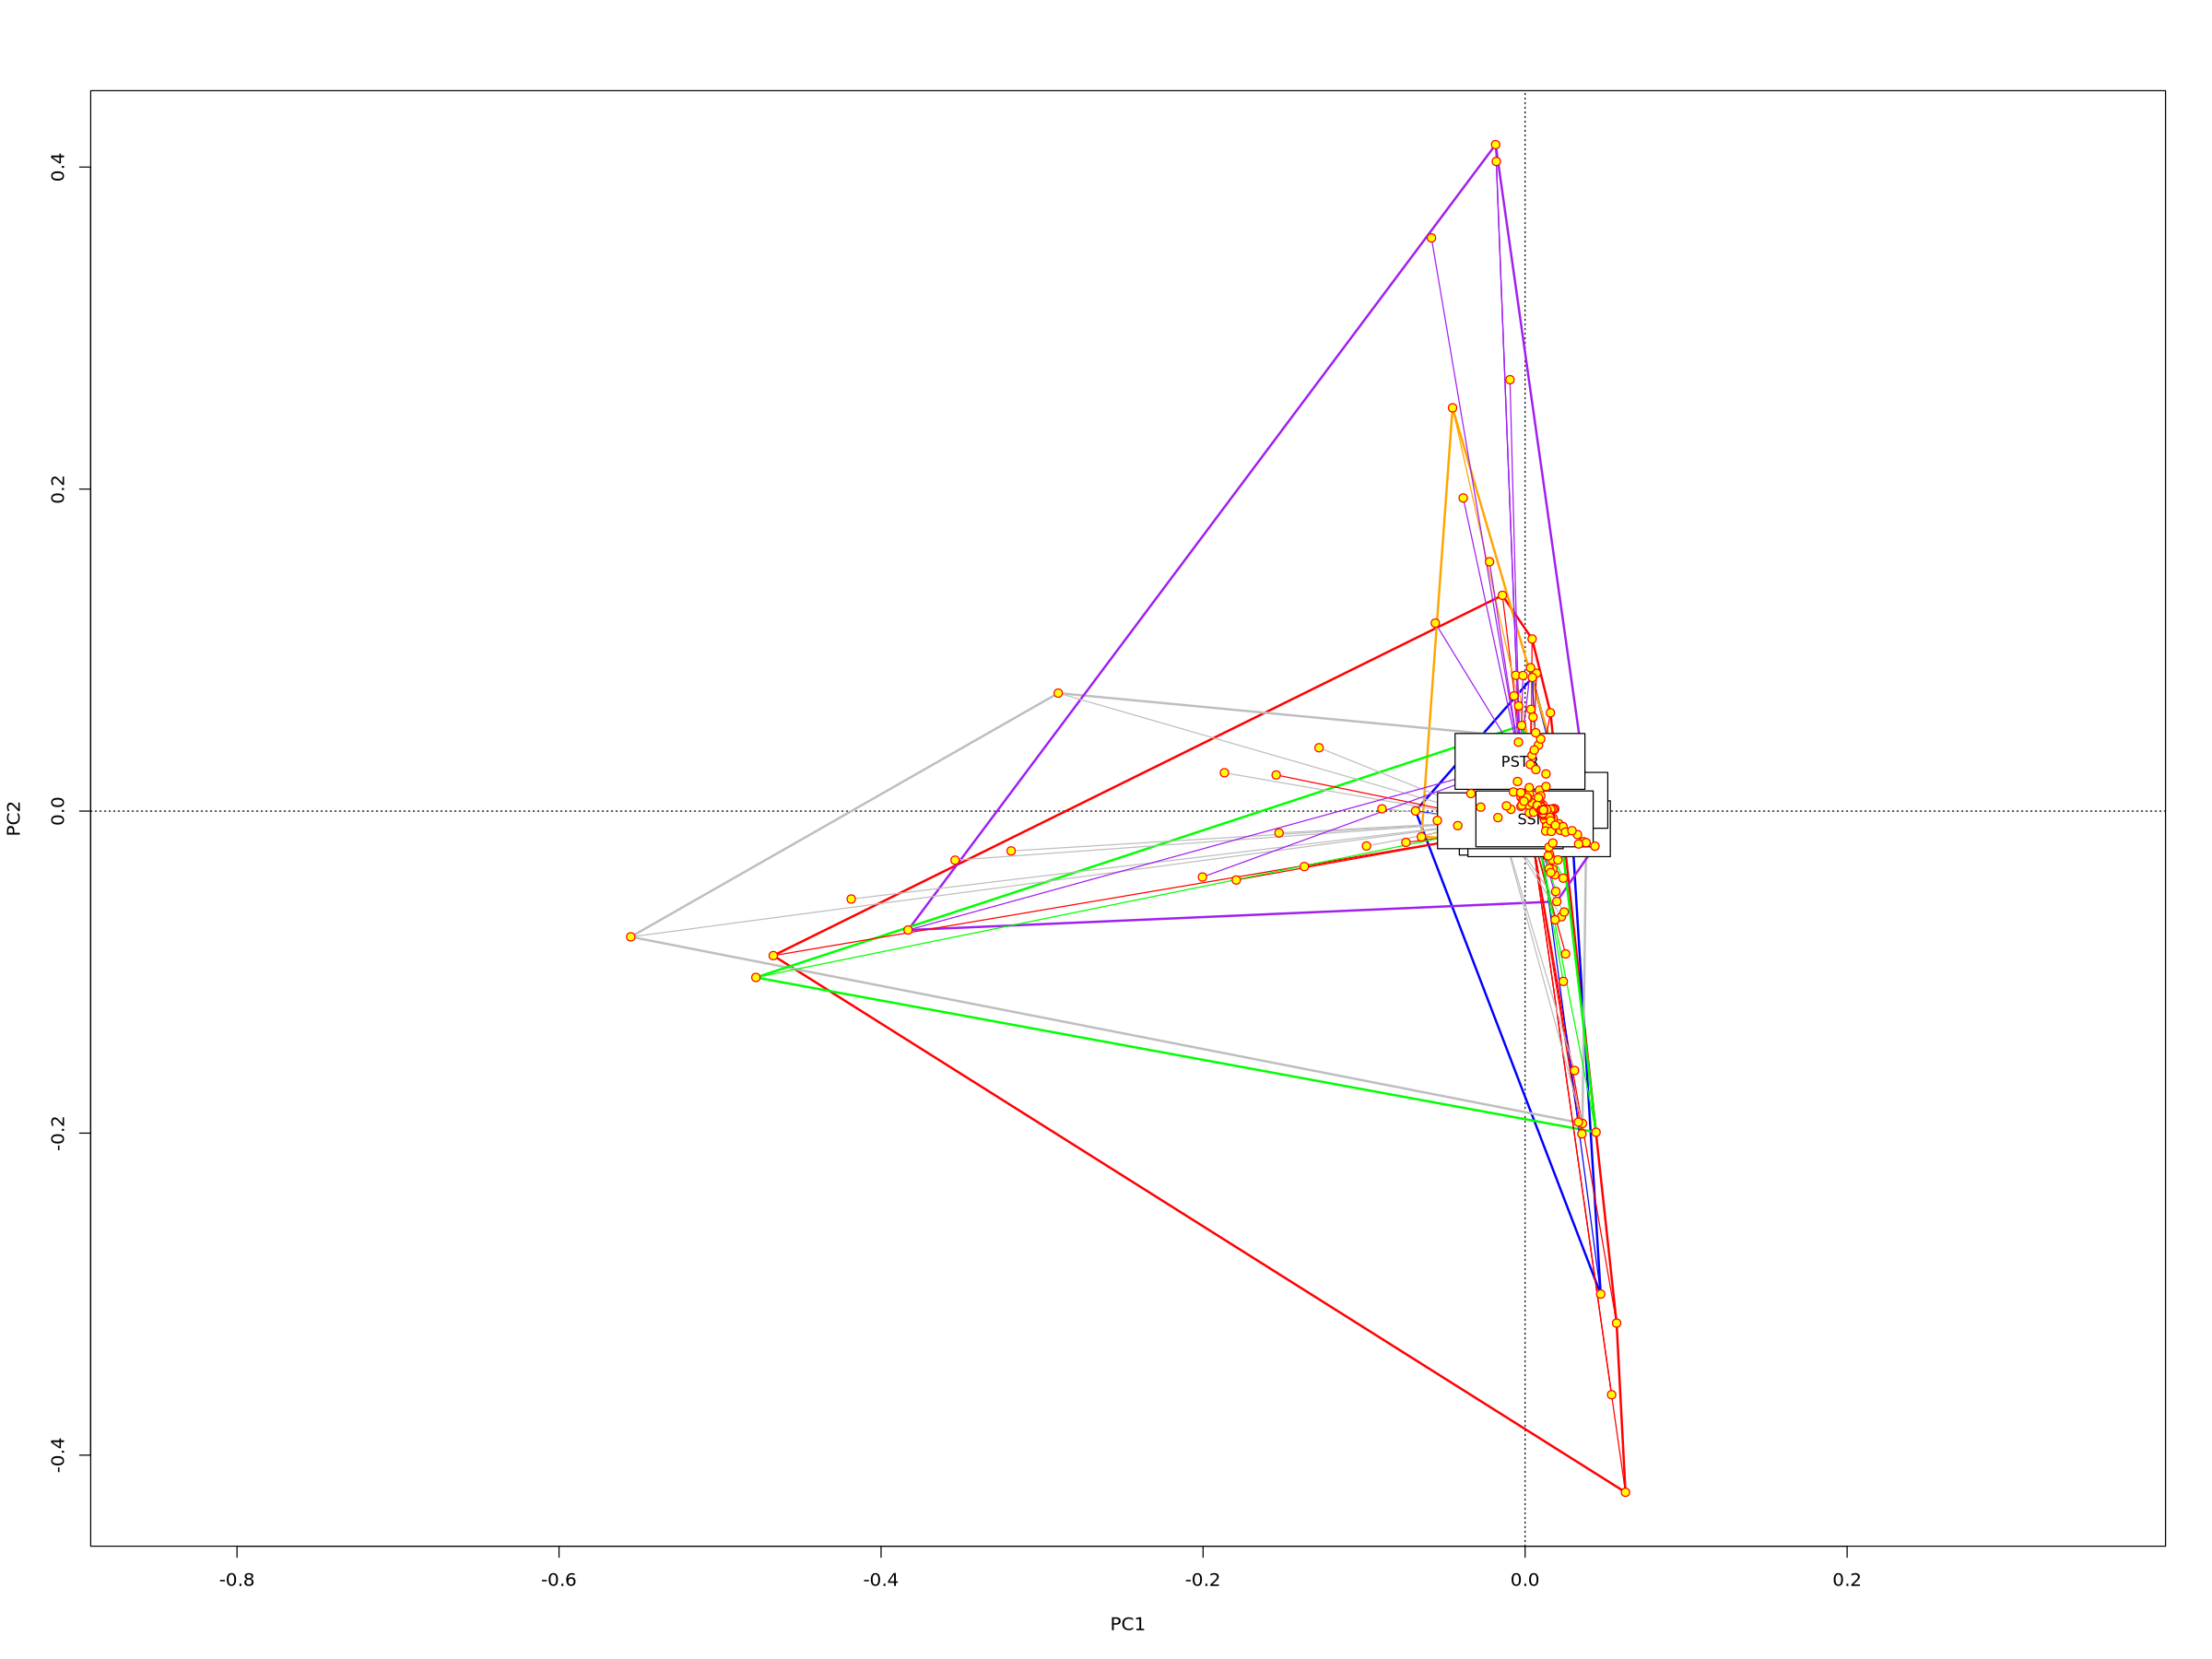

In [44]:
#by species 
disp <- "sites" 
scl <- "symmetric" 

#transforming species col from chr to factor 
otu_merged$Species <- factor(otu_merged$Species)
# PCA via rda()
pca_mod <- rda(ord)
#color points
# Color vector
col_vec <-c("red", "blue", "orange", "grey", "purple", "green")
cols <- col_vec[otu_merged$species]
plot(pca_mod, type = "n", scaling = scl, display = disp) 
ordihull(pca_mod, groups = otu_merged$Species, col = col_vec, scaling = scl, lwd = 2) 
ordispider(pca_mod, groups = otu_merged$Species, col = col_vec, scaling = scl, label = TRUE) 
points(pca_mod, display = disp, scaling = scl, pch = 21, col = "red", bg = "yellow")

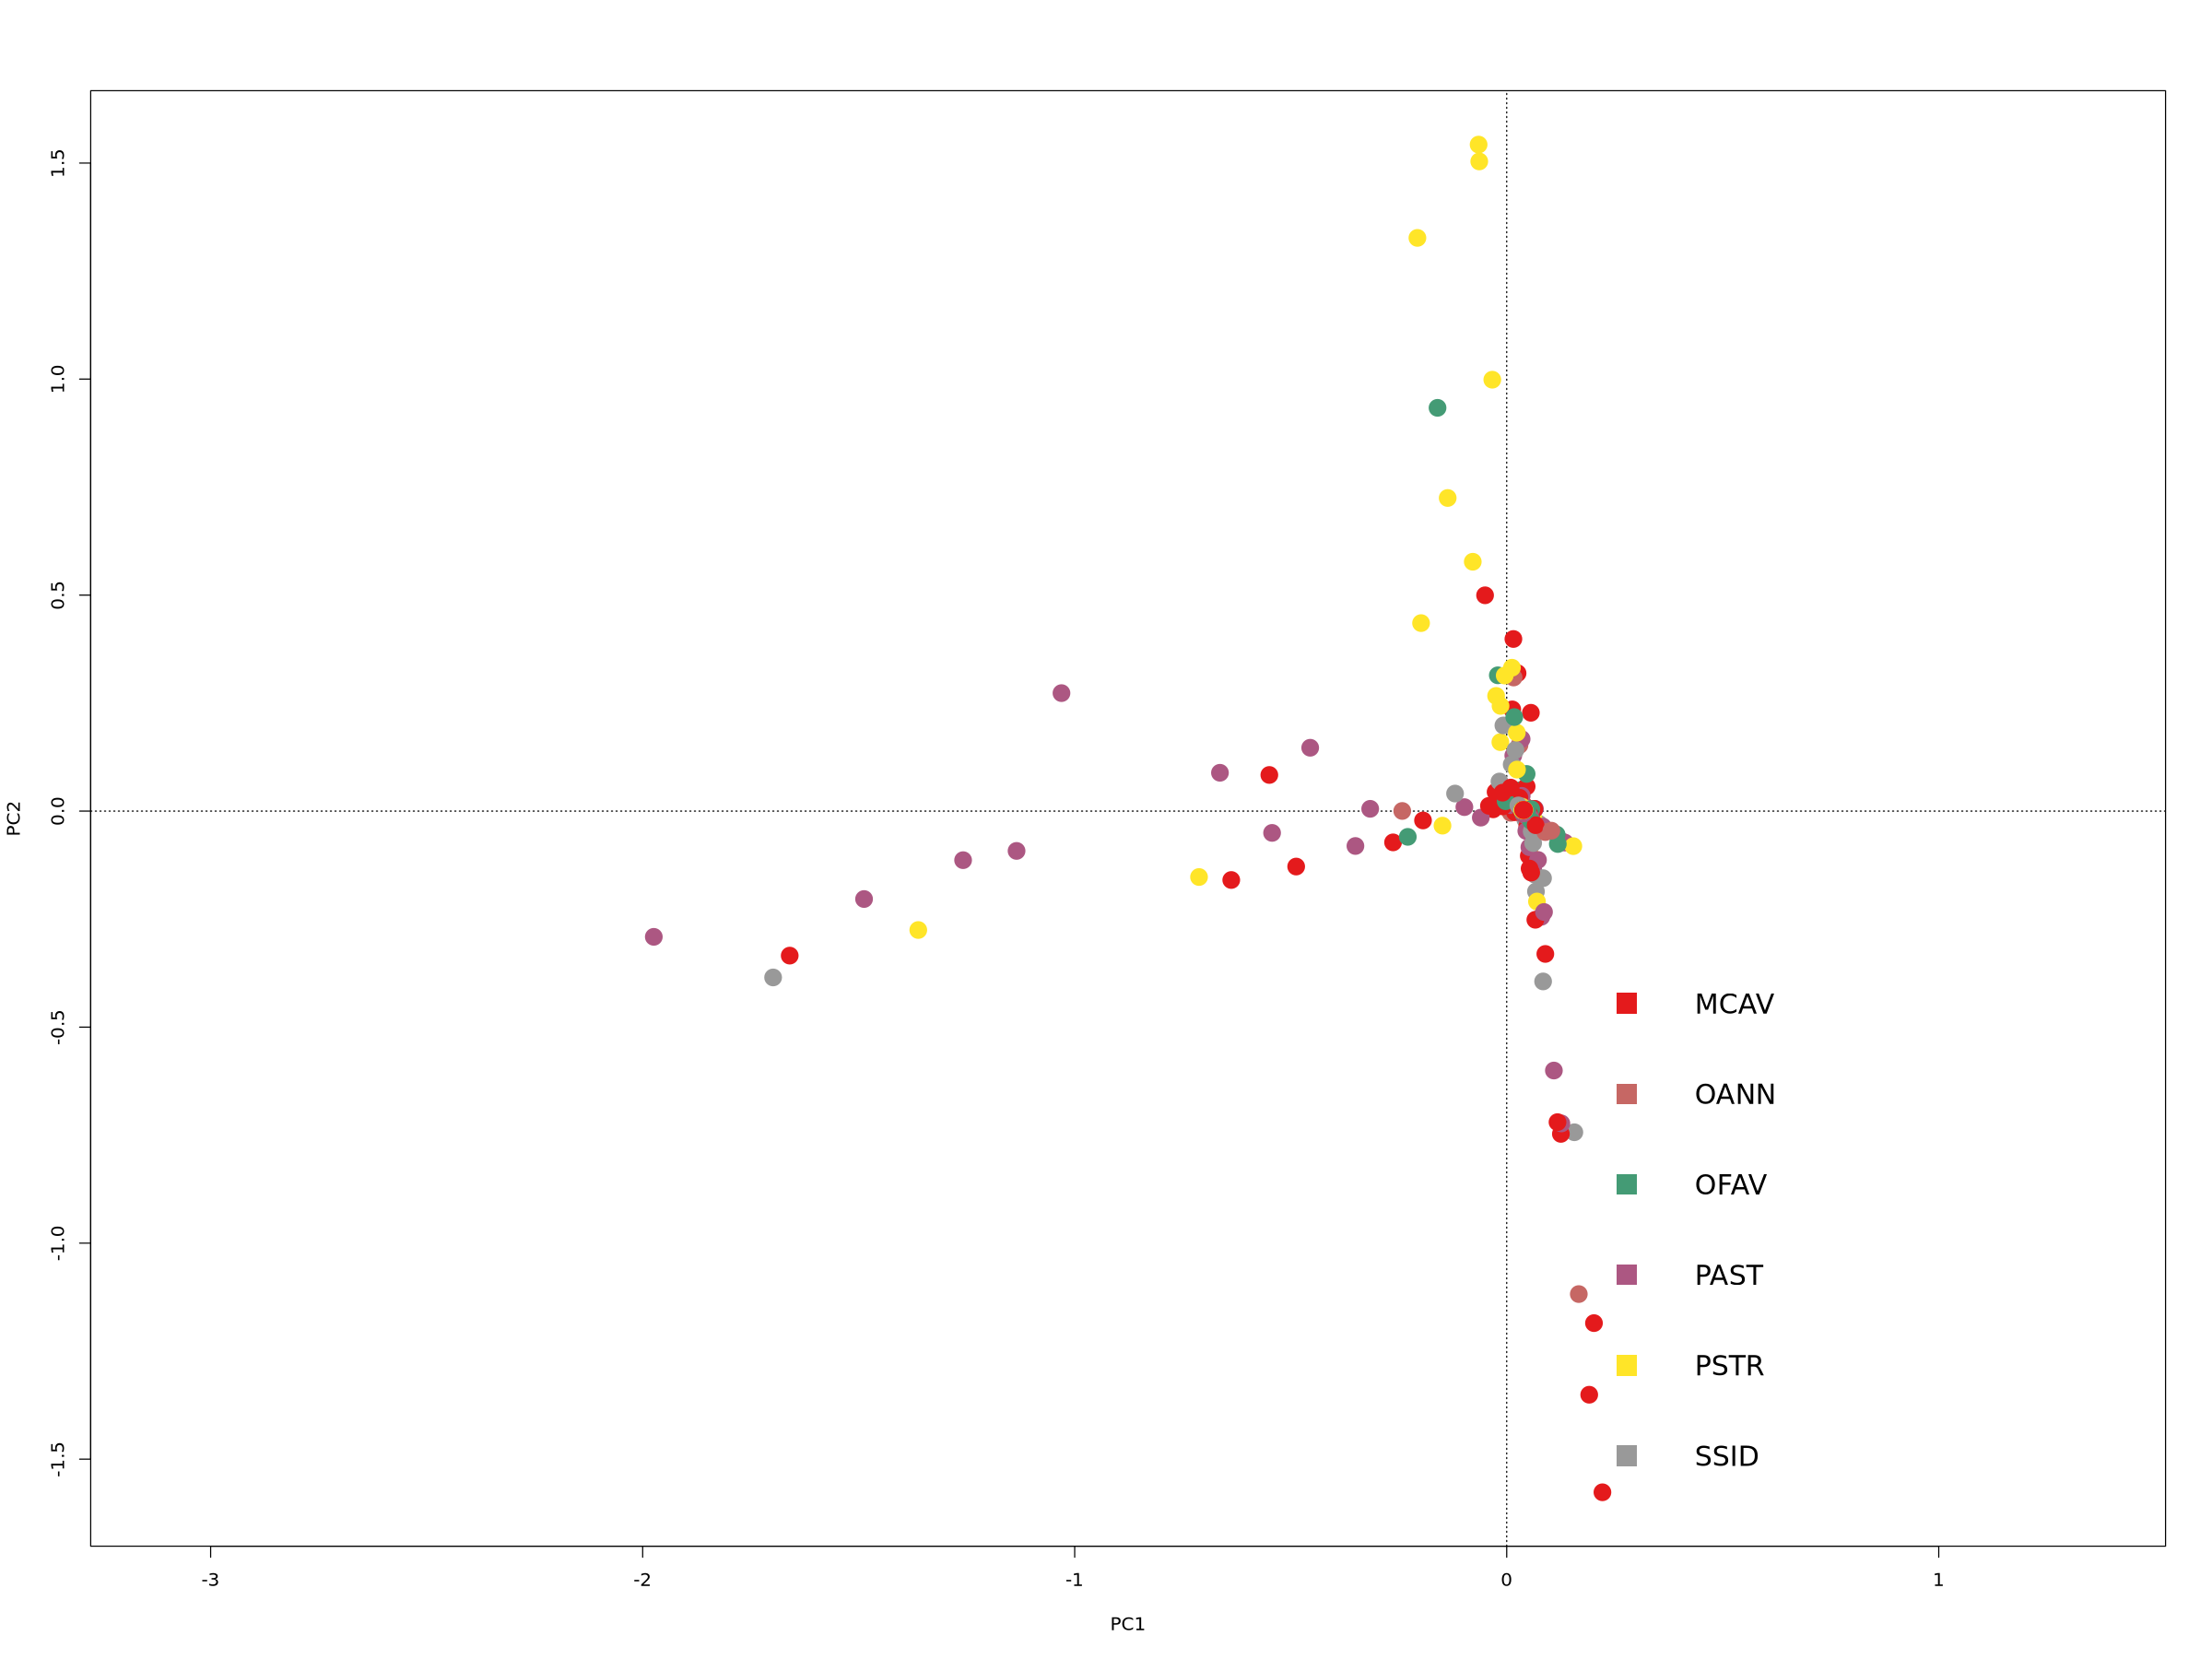

In [55]:
#transforming MonthYear col from chr to factor 
otu_merged$Species <- factor(otu_merged$Species)
# PCA via rda()
pca_spec <- rda(ord)
#color points
# Color vector
col_spec <-colorRampPalette(brewer.pal(9, "Set1"))(6)
# Generate a random set of colors 
    col_spec <- sample(col_spec, 6)
cols <- col_spec[otu_merged$Species]

#plot
plot(pca_spec, type = "n", scaling = 2, display = "sites")

points(pca_spec, display = "sites", scaling = 2,
       pch = 19, col = cols, cex = 2)

legend("bottomright",
       legend = levels(otu_merged$Species),
       bty = "n",
       col = col_spec,
       pch = 15,
       cex = 1.5, pt.cex=2.5)

### make and save PC species plot

In [59]:
png("/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/BEL_16S_ITS2/BEL_16S_outputs/apr_lab_meeting/pca_spec.png", width = 800, height = 600, res = 120)

plot(pca_spec, type = "n", scaling = 2, display = "sites")

points(pca_spec, display = "sites", scaling = 2,
       pch = 19, col = cols, cex = 2)

legend("bottomright",
       legend = levels(otu_merged$Species),
       bty = "n",
       col = col_spec,
       pch = 15,
       cex = 1.5, pt.cex = 2.5)

dev.off()

png 
  2

## dendogram cluster analysis

### different dendogram clustering methods 

#### Maximum or complete linkage clustering: 
- It computes all pairwise dissimilarities between the elements in cluster 1 and the elements in cluster 2, and considers the largest value (i.e., maximum value) of these dissimilarities as the distance between the two clusters. It tends to produce more compact clusters.
#### Minimum or single linkage clustering: 
- It computes all pairwise dissimilarities between the elements in cluster 1 and the elements in cluster 2, and considers the smallest of these dissimilarities as a linkage criterion. It tends to produce long, “loose” clusters.
#### Mean or average linkage clustering: 
- It computes all pairwise dissimilarities between the elements in cluster 1 and the elements in cluster 2, and considers the average of these dissimilarities as the distance between the two clusters.
#### Centroid linkage clustering: 
- It computes the dissimilarity between the centroid for cluster 1 (a mean vector of length p variables) and the centroid for cluster 2.
#### Ward’s minimum variance method: 
- It minimizes the total within-cluster variance. At each step the pair of clusters with minimum between-cluster distance are merged.

In [35]:
dij <- vegdist(otu_nomit) ## bray curtis dissimilarity
clu <- hclust(dij, method = "average") 
# 2 clusters bc I know Date_16S is already driving into 2 clusters
grp <- cutree(clu, 6)

In [67]:
# plot settings
options(repr.plot.width=50, repr.plot.height=18)

In [71]:
png("/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/BEL_16S_ITS2/BEL_16S_outputs/apr_lab_meeting/dendogram_20.png", width = 2000, height = 1000)

plot(clu)
rect.hclust(clu, k = 20, border = "red")

dev.off()

png 
  2

## heatmap with dendogram

# phyloseq NMDS

In [ ]:
#making this plot wider
options(repr.plot.width=30, repr.plot.height=15)
mycolors= colorRampPalette(brewer.pal(9, "Set1"))(20)
# Generate a random set of colors 
    mycolors <- sample(mycolors, 20)

In [ ]:
ps_norm_nmds <- ordinate(ps_norm_nomit, "NMDS", "bray", trymax=1000)

ps_nmds <- plot_ordination(ps_norm_nomit, ps_norm_nmds, type="samples", color="Health_status" )+ 
geom_point(size=12) + 
  labs(title = "NMDS Ordination of all samples with more than 10K reads",
       x = "NMDS1",
       y = "NMDS2") +
  scale_fill_manual(values = mycolors, drop = TRUE) +
  scale_color_manual(values = mycolors, drop = TRUE) +
  theme_bw() +
theme(
    legend.position = "right",
    legend.title = element_text(size = 25),
  legend.text = element_text(size = 20),
  legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.5, "cm"),   # make them taller
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 25)) +

guides(color = guide_legend(override.aes = list(size = 12))) 

ps_norm_nmds